# Performing Cytotrace on AllDC and DC2 objects

# Object prep in python:

In [ ]:
import scanpy as sc
import os
import pandas as pd

In [ ]:
#set current directory 
os.chdir('/scratch/user/s4436039/scdata/Myeloid_Objects')
os.getcwd()

'/scratch/user/s4436039/scdata/Myeloid_Objects'

In [ ]:
#read in the files
#import raw data:
data_raw = sc.read_h5ad('NR_data_intersect.h5ad')
#import clean data for AllDC and DC2:
data_DC = sc.read_h5ad('20250617_AllDC_bbknn.h5ad')
data_DC2 = sc.read_h5ad('20250629_DC2_bbknn_clustered2.h5ad')

In [ ]:
data_raw

AnnData object with n_obs × n_vars = 623908 × 15074
    obs: 'nCount_RNA', 'nFeature_RNA', 'sample_type', 'cancer_type', 'patient_id', 'sample_id', 'percent.mt', 'site', 'sample_type_major', 'cancer_subtype', 'integration_id', 'ident', 'dataset_id'
    var: 'name'

In [ ]:
data_DC

AnnData object with n_obs × n_vars = 29887 × 1746
    obs: 'nCount_RNA', 'nFeature_RNA', 'sample_type', 'cancer_type', 'patient_id', 'sample_id', 'percent.mt', 'site', 'sample_type_major', 'cancer_subtype', 'integration_id', 'ident', 'dataset_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'S_score', 'G2M_score', 'keep_or_remove', 'leiden', 'celltype', 'leiden_DC', 'leiden_DC_v2', 'exclude_annots', 'leiden_M', 'Technology', 'NR_annotations_simple', 'sample_type_major2', 'cancer_with_H', 'cancer_broadest', 'patient_treatment', 'DC1_sig', 'DC2_sig', 'DC3_sig', 'mregDC_sig'
    var: 'name', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions'

In [ ]:
data_DC2

AnnData object with n_obs × n_vars = 16643 × 2001
    obs: 'nCount_RNA', 'nFeature_RNA', 'sample_type', 'cancer_type', 'patient_id', 'sample_id', 'percent.mt', 'site', 'sample_type_major', 'cancer_subtype', 'integration_id', 'ident', 'dataset_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'S_score', 'G2M_score', 'keep_or_remove', 'leiden', 'celltype', 'leiden_DC', 'leiden_DC_v2', 'exclude_annots', 'leiden_M', 'Technology', 'NR_annotations_simple', 'sample_type_major2', 'cancer_with_H', 'cancer_broadest', 'patient_treatment', 'Guimaraes_DC2_FCER1A', 'Guimaraes_DC2_AREG', 'Guimaraes_Cheng_DC2_CD207/CD1A', 'Guimaraes_DC3_CD14', 'Guimaraes_DC4_FCGR3A', 'Guimaraes_DC_CXCL2', 'Cheng_DC2_CXCR4', 'Cheng_DC2_IL1B', 'Cheng_DC2_FCN1', 'Cheng_DC2_ISG15', 'Cheng_DC2_CXCL9', 

## subset the raw data to only the cells of interest (AllDC and DC2)

In [ ]:
# subset the raw data to only the cells of interest (AllDC and DC2)

#AllDC:
# Get the list of barcodes (cell names) in data_clean
barcodes_to_keep_AllDC = data_DC.obs.index
# subset data_raw to just those in data_clean
data_raw_DC = data_raw[data_raw.obs.index.isin(barcodes_to_keep_AllDC), :]
data_raw_DC

View of AnnData object with n_obs × n_vars = 29887 × 15074
    obs: 'nCount_RNA', 'nFeature_RNA', 'sample_type', 'cancer_type', 'patient_id', 'sample_id', 'percent.mt', 'site', 'sample_type_major', 'cancer_subtype', 'integration_id', 'ident', 'dataset_id'
    var: 'name'

In [ ]:
# subset the raw data to only the cells of interest (AllDC and DC2)

#DC2:
# Get the list of barcodes (cell names) in data_clean
barcodes_to_keep_DC2 = data_DC2.obs.index
# subset data_raw to just those in data_clean
data_raw_DC2 = data_raw[data_raw.obs.index.isin(barcodes_to_keep_DC2), :]
data_raw_DC2

View of AnnData object with n_obs × n_vars = 16643 × 15074
    obs: 'nCount_RNA', 'nFeature_RNA', 'sample_type', 'cancer_type', 'patient_id', 'sample_id', 'percent.mt', 'site', 'sample_type_major', 'cancer_subtype', 'integration_id', 'ident', 'dataset_id'
    var: 'name'

## transfer desired metadata to raw objects:

In [ ]:
meta_columns_DC = ['NR_annotations_simple']
meta_columns_DC2 = ['cDC2_Atlas_Subclusters']

In [ ]:
# Subset the metadata in data_DC and data_DC2 to match data_raw_DC and data_raw_DC2's barcodes
metadata_to_transfer_DC = data_DC.obs.loc[data_raw_DC.obs.index, meta_columns_DC]
metadata_to_transfer_DC2 = data_DC2.obs.loc[data_raw_DC2.obs.index, meta_columns_DC2]

In [ ]:
# Add these columns to raw data's obs
for col in meta_columns_DC:
    data_raw_DC.obs[col] = metadata_to_transfer_DC[col]

for col in meta_columns_DC2:
    data_raw_DC2.obs[col] = metadata_to_transfer_DC2[col]

/scratch/temp/23563648/ipykernel_1118459/2346259706.py:3: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  data_raw_DC.obs[col] = metadata_to_transfer_DC[col]
/scratch/temp/23563648/ipykernel_1118459/2346259706.py:6: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  data_raw_DC2.obs[col] = metadata_to_transfer_DC2[col]


In [ ]:
# Verify that the metadata was transferred
data_raw_DC.obs.tail()

,nCount_RNA,nFeature_RNA,sample_type,cancer_type,patient_id,sample_id,percent.mt,site,sample_type_major,cancer_subtype,integration_id,ident,dataset_id,NR_annotations_simple
GSE180661_HGSOC_SPECTRUM-OV-045_S1_CD45P_LEFT_OVARY_GTTTACTCAAGGCCTC,-9.995153,-8.131683,Adnexa,HGSOC,Left Adnexa,SPECTRUM-OV-045_S1_CD45P_LEFT_OVARY,2694.0,ovary,primary tumour,HGSOC,GSE180661_SPECTRUM-OV-045_S1_CD45P_LEFT_OVARY,all_integrated_intersect,GSE180661,cDC1
GSE180661_HGSOC_SPECTRUM-OV-045_S1_CD45P_LEFT_OVARY_TACCGAACAAACCGGA,-9.134331,-8.627023,Adnexa,HGSOC,Left Adnexa,SPECTRUM-OV-045_S1_CD45P_LEFT_OVARY,839.0,ovary,primary tumour,HGSOC,GSE180661_SPECTRUM-OV-045_S1_CD45P_LEFT_OVARY,all_integrated_intersect,GSE180661,cDC2
GSE180661_HGSOC_SPECTRUM-OV-045_S1_CD45P_LEFT_OVARY_TCACGCTTCCGTCACT,-10.033317,-7.518040,Adnexa,HGSOC,Left Adnexa,SPECTRUM-OV-045_S1_CD45P_LEFT_OVARY,1683.0,ovary,primary tumour,HGSOC,GSE180661_SPECTRUM-OV-045_S1_CD45P_LEFT_OVARY,all_integrated_intersect,GSE180661,mregDC
GSE180661_HGSOC_SPECTRUM-OV-045_S1_CD45P_LEFT_OVARY_TGCAGTAGTGTTGCCG,-9.364501,-8.566583,Adnexa,HGSOC,Left Adnexa,SPECTRUM-OV-045_S1_CD45P_LEFT_OVARY,2257.0,ovary,primary tumour,HGSOC,GSE180661_SPECTRUM-OV-045_S1_CD45P_LEFT_OVARY,all_integrated_intersect,GSE180661,cDC2
GSE180661_HGSOC_SPECTRUM-OV-045_S1_CD45P_LEFT_OVARY_TGTGAGTTCGGAAACG,-9.738727,-7.459797,Adnexa,HGSOC,Left Adnexa,SPECTRUM-OV-045_S1_CD45P_LEFT_OVARY,949.0,ovary,primary tumour,HGSOC,GSE180661_SPECTRUM-OV-045_S1_CD45P_LEFT_OVARY,all_integrated_intersect,GSE180661,mregDC


In [ ]:
# Verify that the metadata was transferred
data_raw_DC2.obs.tail()

,nCount_RNA,nFeature_RNA,sample_type,cancer_type,patient_id,sample_id,percent.mt,site,sample_type_major,cancer_subtype,integration_id,ident,dataset_id,cDC2_Atlas_Subclusters
GSE180661_HGSOC_SPECTRUM-OV-118_S1_CD45P_LEFT_ADNEXA_TGATCAGCAGTGTGCC,-9.194493,-8.535726,Adnexa,HGSOC,Left Adnexa,SPECTRUM-OV-118_S1_CD45P_LEFT_ADNEXA,2133.0,ovary,primary tumour,HGSOC,GSE180661_SPECTRUM-OV-118_S1_CD45P_LEFT_ADNEXA,all_integrated_intersect,GSE180661,8
GSE180661_HGSOC_SPECTRUM-OV-118_S1_CD45P_LEFT_ADNEXA_TGCGGCACAGAGGAAA,-9.025559,-8.786784,Adnexa,HGSOC,Left Adnexa,SPECTRUM-OV-118_S1_CD45P_LEFT_ADNEXA,2122.0,ovary,primary tumour,HGSOC,GSE180661_SPECTRUM-OV-118_S1_CD45P_LEFT_ADNEXA,all_integrated_intersect,GSE180661,5
GSE180661_HGSOC_SPECTRUM-OV-118_S1_CD45P_LEFT_ADNEXA_TGGAGAGAGGCTTCCG,-8.552586,-8.416667,Adnexa,HGSOC,Left Adnexa,SPECTRUM-OV-118_S1_CD45P_LEFT_ADNEXA,2330.0,ovary,primary tumour,HGSOC,GSE180661_SPECTRUM-OV-118_S1_CD45P_LEFT_ADNEXA,all_integrated_intersect,GSE180661,5
GSE180661_HGSOC_SPECTRUM-OV-118_S1_CD45P_LEFT_ADNEXA_TGTTGAGCAGCAAGAC,-9.298763,-8.526468,Adnexa,HGSOC,Left Adnexa,SPECTRUM-OV-118_S1_CD45P_LEFT_ADNEXA,1333.0,ovary,primary tumour,HGSOC,GSE180661_SPECTRUM-OV-118_S1_CD45P_LEFT_ADNEXA,all_integrated_intersect,GSE180661,5
GSE180661_HGSOC_SPECTRUM-OV-118_S1_CD45P_LEFT_ADNEXA_TTCTTCCTCGCCACTT,-8.426378,-8.466942,Adnexa,HGSOC,Left Adnexa,SPECTRUM-OV-118_S1_CD45P_LEFT_ADNEXA,1899.0,ovary,primary tumour,HGSOC,GSE180661_SPECTRUM-OV-118_S1_CD45P_LEFT_ADNEXA,all_integrated_intersect,GSE180661,1


## Export h5ad objects

In [ ]:
#export unintegrated (raw) DC objects as a h5ad object for use in seurat cytotrace
data_raw_DC.write_h5ad("20260412_Cytotrace_Raw_DC.h5ad", compression="gzip")
data_raw_DC2.write_h5ad("20260412_Cytotrace_Raw_DC2.h5ad", compression="gzip")

# Perform cytotrace in R on Raw data files exported above:

In [1]:
#set wd
getwd()
setwd('/scratch/user/s4436039/scdata/Myeloid_Objects')
getwd()

[1] "/scratch/user/s4436039/Nikita-project"

[1] "/scratch/user/s4436039/scdata/Myeloid_Objects"

In [ ]:
library(Seurat)
library(sceasy)
library(reticulate)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Loading required package: reticulate



In [ ]:
h5ad_path_DC = "20260412_Cytotrace_Raw_DC.h5ad"
h5ad_path_DC2 = "20260412_Cytotrace_Raw_DC2.h5ad"

In [ ]:
#convert h5ad to seurat
sceasy::convertFormat(h5ad_path_DC, from="anndata", to="seurat",
                       outFile='20260412_NR_raw_DC_R.rds')

X -> counts



An object of class Seurat 
15074 features across 29887 samples within 1 assay 
Active assay: RNA (15074 features, 0 variable features)
 2 layers present: counts, data

In [ ]:
sceasy::convertFormat(h5ad_path_DC2, from="anndata", to="seurat",
                       outFile='20260412_NR_raw_DC2_R.rds')

X -> counts



An object of class Seurat 
15074 features across 16643 samples within 1 assay 
Active assay: RNA (15074 features, 0 variable features)
 2 layers present: counts, data

In [ ]:
data_DC = readRDS('20260412_NR_raw_DC_R.rds')
head(data_DC@meta.data)
data_DC2 = readRDS('20260412_NR_raw_DC2_R.rds')
head(data_DC2@meta.data)

,nCount_RNA,nFeature_RNA,sample_type,cancer_type,patient_id,sample_id,percent.mt,site,sample_type_major,cancer_subtype,integration_id,ident,dataset_id,NR_annotations_simple
,<dbl>,<dbl>,<fct>,<fct>,<fct>,<fct>,<dbl>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>
GSE215120_AM1_AAATGCCCAGAGCCAA-1,17143,2659,tumour,Acral Melanoma,AM1,GSE215120_Acral_MEL_AM1,1.224990,skin,primary tumour,Acral Melanoma,GSE215120_Acral_MEL_AM1,all_integrated_intersect,GSE215120,cDC2
GSE215120_AM1_ACACTGATCCACTGGG-1,18333,2845,tumour,Acral Melanoma,AM1,GSE215120_Acral_MEL_AM1,1.063656,skin,primary tumour,Acral Melanoma,GSE215120_Acral_MEL_AM1,all_integrated_intersect,GSE215120,cDC2
GSE215120_AM1_ACAGCCGCAAACCTAC-1,10581,2182,tumour,Acral Melanoma,AM1,GSE215120_Acral_MEL_AM1,2.050846,skin,primary tumour,Acral Melanoma,GSE215120_Acral_MEL_AM1,all_integrated_intersect,GSE215120,cDC2
GSE215120_AM1_ACCAGTAAGACTGGGT-1,8015,1488,tumour,Acral Melanoma,AM1,GSE215120_Acral_MEL_AM1,2.033687,skin,primary tumour,Acral Melanoma,GSE215120_Acral_MEL_AM1,all_integrated_intersect,GSE215120,cDC1
GSE215120_AM1_ACGTCAACAAGGACTG-1,25642,4010,tumour,Acral Melanoma,AM1,GSE215120_Acral_MEL_AM1,2.835192,skin,primary tumour,Acral Melanoma,GSE215120_Acral_MEL_AM1,all_integrated_intersect,GSE215120,cDC1
GSE215120_AM1_ACGTCAATCCGCATCT-1,9833,2074,tumour,Acral Melanoma,AM1,GSE215120_Acral_MEL_AM1,1.311909,skin,primary tumour,Acral Melanoma,GSE215120_Acral_MEL_AM1,all_integrated_intersect,GSE215120,cDC2


,nCount_RNA,nFeature_RNA,sample_type,cancer_type,patient_id,sample_id,percent.mt,site,sample_type_major,cancer_subtype,integration_id,ident,dataset_id,cDC2_Atlas_Subclusters
,<dbl>,<dbl>,<fct>,<fct>,<fct>,<fct>,<dbl>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>
GSE215120_AM1_AAATGCCCAGAGCCAA-1,17143,2659,tumour,Acral Melanoma,AM1,GSE215120_Acral_MEL_AM1,1.224990,skin,primary tumour,Acral Melanoma,GSE215120_Acral_MEL_AM1,all_integrated_intersect,GSE215120,1
GSE215120_AM1_ACACTGATCCACTGGG-1,18333,2845,tumour,Acral Melanoma,AM1,GSE215120_Acral_MEL_AM1,1.063656,skin,primary tumour,Acral Melanoma,GSE215120_Acral_MEL_AM1,all_integrated_intersect,GSE215120,1
GSE215120_AM1_ACAGCCGCAAACCTAC-1,10581,2182,tumour,Acral Melanoma,AM1,GSE215120_Acral_MEL_AM1,2.050846,skin,primary tumour,Acral Melanoma,GSE215120_Acral_MEL_AM1,all_integrated_intersect,GSE215120,1
GSE215120_AM1_ACGTCAATCCGCATCT-1,9833,2074,tumour,Acral Melanoma,AM1,GSE215120_Acral_MEL_AM1,1.311909,skin,primary tumour,Acral Melanoma,GSE215120_Acral_MEL_AM1,all_integrated_intersect,GSE215120,5
GSE215120_AM1_ACTTGTTTCTGAAAGA-1,7887,1846,tumour,Acral Melanoma,AM1,GSE215120_Acral_MEL_AM1,2.738684,skin,primary tumour,Acral Melanoma,GSE215120_Acral_MEL_AM1,all_integrated_intersect,GSE215120,5
GSE215120_AM1_AGAGCTTGTACAGTTC-1,17339,2817,tumour,Acral Melanoma,AM1,GSE215120_Acral_MEL_AM1,2.612607,skin,primary tumour,Acral Melanoma,GSE215120_Acral_MEL_AM1,all_integrated_intersect,GSE215120,1


In [ ]:
library(CytoTRACE)

Welcome to the CytoTRACE R package, a tool for the unbiased prediction of differentiation states in scRNA-seq data. For more information about this method, visit https://cytotrace.stanford.edu.


Warning message:
“The ScanoramaCT python module is not accessible. The iCytoTRACE function for integration across multiple datasets will be disabled. Please follow the instructions in https://github.com/gunsagargulati/CytoTRACE to install the necessary Python packages for this application.”


In [ ]:
#extract expression data
expression_data_DC <- GetAssayData(data_DC)
expression_data_DC <- as.data.frame(as.matrix(expression_data_DC))

expression_data_DC2 <- GetAssayData(data_DC2)
expression_data_DC2 <- as.data.frame(as.matrix(expression_data_DC2))

Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 3.4 GiB”
Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 1.9 GiB”


In [ ]:
head(expression_data_DC)
head(expression_data_DC2)

,GSE215120_AM1_AAATGCCCAGAGCCAA-1,GSE215120_AM1_ACACTGATCCACTGGG-1,GSE215120_AM1_ACAGCCGCAAACCTAC-1,GSE215120_AM1_ACCAGTAAGACTGGGT-1,GSE215120_AM1_ACGTCAACAAGGACTG-1,GSE215120_AM1_ACGTCAATCCGCATCT-1,GSE215120_AM1_ACTGAGTCAGGCTGAA-1,GSE215120_AM1_ACTGTCCGTCTCTTAT-1,GSE215120_AM1_ACTTGTTTCTGAAAGA-1,GSE215120_AM1_AGAGCTTGTACAGTTC-1,⋯,GSE180661_HGSOC_SPECTRUM-OV-045_S1_CD45P_LEFT_OVARY_CGGGCATTCTTCTGTA,GSE180661_HGSOC_SPECTRUM-OV-045_S1_CD45P_LEFT_OVARY_CTACGGGGTGATCGTT,GSE180661_HGSOC_SPECTRUM-OV-045_S1_CD45P_LEFT_OVARY_CTCATGCTCGTTAGAC,GSE180661_HGSOC_SPECTRUM-OV-045_S1_CD45P_LEFT_OVARY_CTTGATTAGCAGGTCA,GSE180661_HGSOC_SPECTRUM-OV-045_S1_CD45P_LEFT_OVARY_GAGGGATCAAGCGCTC,GSE180661_HGSOC_SPECTRUM-OV-045_S1_CD45P_LEFT_OVARY_GTTTACTCAAGGCCTC,GSE180661_HGSOC_SPECTRUM-OV-045_S1_CD45P_LEFT_OVARY_TACCGAACAAACCGGA,GSE180661_HGSOC_SPECTRUM-OV-045_S1_CD45P_LEFT_OVARY_TCACGCTTCCGTCACT,GSE180661_HGSOC_SPECTRUM-OV-045_S1_CD45P_LEFT_OVARY_TGCAGTAGTGTTGCCG,GSE180661_HGSOC_SPECTRUM-OV-045_S1_CD45P_LEFT_OVARY_TGTGAGTTCGGAAACG
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
FAM87B,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
LINC00115,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
FAM41C,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
SAMD11,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
NOC2L,0,0,0,0,1,1,0,0,0,0,⋯,0,0,1,0,0,1,0,0,0,0
KLHL17,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0


,GSE215120_AM1_AAATGCCCAGAGCCAA-1,GSE215120_AM1_ACACTGATCCACTGGG-1,GSE215120_AM1_ACAGCCGCAAACCTAC-1,GSE215120_AM1_ACGTCAATCCGCATCT-1,GSE215120_AM1_ACTTGTTTCTGAAAGA-1,GSE215120_AM1_AGAGCTTGTACAGTTC-1,GSE215120_AM1_AGGGATGGTTTGTGTG-1,GSE215120_AM1_AGGTCATAGTACGCGA-1,GSE215120_AM1_AGGTCCGCATTCTTAC-1,GSE215120_AM1_ATCCACCCAGACGCTC-1,⋯,GSE180661_HGSOC_SPECTRUM-OV-118_S1_CD45P_LEFT_ADNEXA_TAGGGTTCAGACCTGC,GSE180661_HGSOC_SPECTRUM-OV-118_S1_CD45P_LEFT_ADNEXA_TATCAGGTCCACACAA,GSE180661_HGSOC_SPECTRUM-OV-118_S1_CD45P_LEFT_ADNEXA_TATCTTGAGGAACGAA,GSE180661_HGSOC_SPECTRUM-OV-118_S1_CD45P_LEFT_ADNEXA_TCATTACAGGAAGTGA,GSE180661_HGSOC_SPECTRUM-OV-118_S1_CD45P_LEFT_ADNEXA_TCTACATGTACCGTCG,GSE180661_HGSOC_SPECTRUM-OV-118_S1_CD45P_LEFT_ADNEXA_TGATCAGCAGTGTGCC,GSE180661_HGSOC_SPECTRUM-OV-118_S1_CD45P_LEFT_ADNEXA_TGCGGCACAGAGGAAA,GSE180661_HGSOC_SPECTRUM-OV-118_S1_CD45P_LEFT_ADNEXA_TGGAGAGAGGCTTCCG,GSE180661_HGSOC_SPECTRUM-OV-118_S1_CD45P_LEFT_ADNEXA_TGTTGAGCAGCAAGAC,GSE180661_HGSOC_SPECTRUM-OV-118_S1_CD45P_LEFT_ADNEXA_TTCTTCCTCGCCACTT
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
FAM87B,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
LINC00115,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,1,0,0,0,0,0
FAM41C,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,1,0,0,0,0,0
SAMD11,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
NOC2L,0,0,0,1,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,1,0,1
KLHL17,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,1,0,0,0,0


In [ ]:
#check if any cells are zero for all genes
zero_cells_DC <- apply(expression_data_DC, 2, function(x) all(x == 0))
zero_cells_DC2 <- apply(expression_data_DC2, 2, function(x) all(x == 0))

In [ ]:
# Identify the columns (cell ids) that are zero for all genes
cells_zero_all_genes <- names(zero_cells_DC[zero_cells_DC == TRUE])
print(cells_zero_all_genes)

cells_zero_all_genes2 <- names(zero_cells_DC2[zero_cells_DC2 == TRUE])
print(cells_zero_all_genes2)

character(0)
character(0)


In [ ]:
#extract annotation data
meta_DC <- data_DC@meta.data
annotation_data_DC <- data.frame(
  cell_id = rownames(meta_DC),  
  annotation = meta_DC$NR_annotations_simple  
)

meta_DC2 <- data_DC2@meta.data
annotation_data_DC2 <- data.frame(
  cell_id = rownames(meta_DC2),  
  annotation = meta_DC2$cDC2_Atlas_Subclusters  
)

In [ ]:
colnames(annotation_data_DC) <- NULL
rownames(annotation_data_DC) <- NULL

colnames(annotation_data_DC2) <- NULL
rownames(annotation_data_DC2) <- NULL

In [ ]:
head(annotation_data_DC)
head(annotation_data_DC2)

1,GSE215120_AM1_AAATGCCCAGAGCCAA-1,cDC2
2,GSE215120_AM1_ACACTGATCCACTGGG-1,cDC2
3,GSE215120_AM1_ACAGCCGCAAACCTAC-1,cDC2
4,GSE215120_AM1_ACCAGTAAGACTGGGT-1,cDC1
5,GSE215120_AM1_ACGTCAACAAGGACTG-1,cDC1
6,GSE215120_AM1_ACGTCAATCCGCATCT-1,cDC2


1,GSE215120_AM1_AAATGCCCAGAGCCAA-1,1
2,GSE215120_AM1_ACACTGATCCACTGGG-1,1
3,GSE215120_AM1_ACAGCCGCAAACCTAC-1,1
4,GSE215120_AM1_ACGTCAATCCGCATCT-1,5
5,GSE215120_AM1_ACTTGTTTCTGAAAGA-1,5
6,GSE215120_AM1_AGAGCTTGTACAGTTC-1,1


In [ ]:
dim(expression_data_DC)
dim(annotation_data_DC)

dim(expression_data_DC2)
dim(annotation_data_DC2)

[1] 15074 29887

[1] 29887     2

[1] 15074 16643

[1] 16643     2

## Run cytotrace: 

In [ ]:
# Run cytotrace on AllDC
Results_DC <- CytoTRACE(expression_data_DC)

The number of cells in your dataset exceeds 3,000. CytoTRACE will now be run in fast mode (see documentation). You can multi-thread this run using the 'ncores' flag. To disable fast mode, please indicate 'enableFast = FALSE'.

Warning message in CytoTRACE(expression_data_DC):
“35 genes have zero expression in the matrix and were filtered”
CytoTRACE will be run on 30 sub-sample(s) of approximately 996 cells each using 1 / 1 core(s)

Pre-processing data and generating similarity matrix...

Calculating gene counts signature...

Smoothing values with NNLS regression and diffusion...

Calculating genes associated with CytoTRACE...

Done



In [ ]:
# Run cytotrace on DC2
Results_DC2 <- CytoTRACE(expression_data_DC2)

The number of cells in your dataset exceeds 3,000. CytoTRACE will now be run in fast mode (see documentation). You can multi-thread this run using the 'ncores' flag. To disable fast mode, please indicate 'enableFast = FALSE'.

Warning message in CytoTRACE(expression_data_DC2):
“92 genes have zero expression in the matrix and were filtered”
CytoTRACE will be run on 17 sub-sample(s) of approximately 979 cells each using 1 / 1 core(s)

Pre-processing data and generating similarity matrix...

Calculating gene counts signature...

Smoothing values with NNLS regression and diffusion...

Calculating genes associated with CytoTRACE...

Done



Running t-SNE. To use your own coordinates, use the 'emb' flag.

Running t-SNE. To use your own coordinates, use the 'emb' flag.



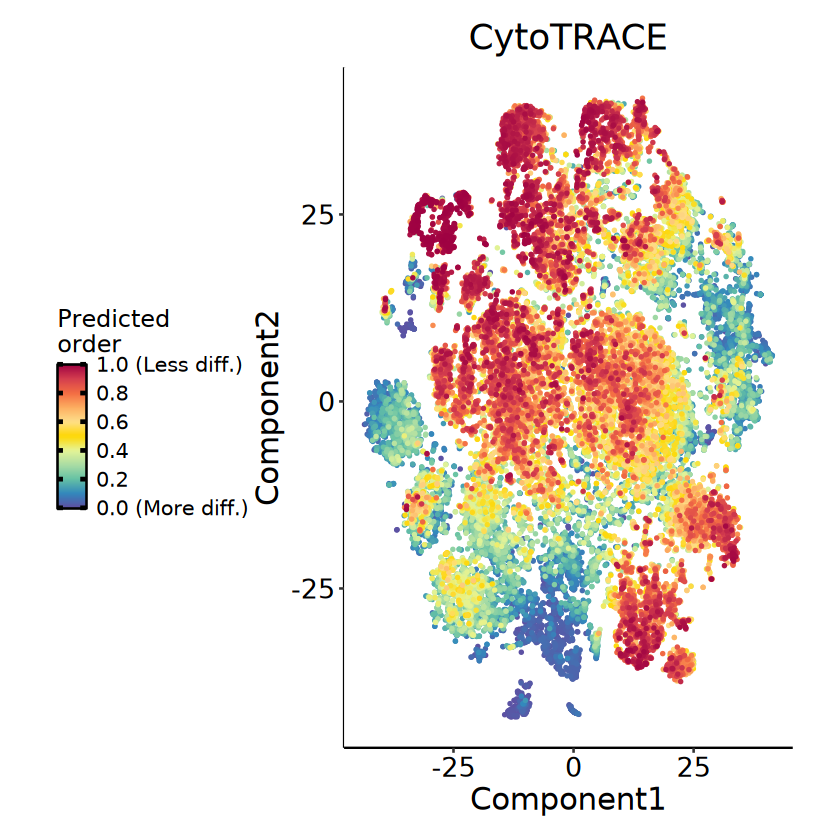

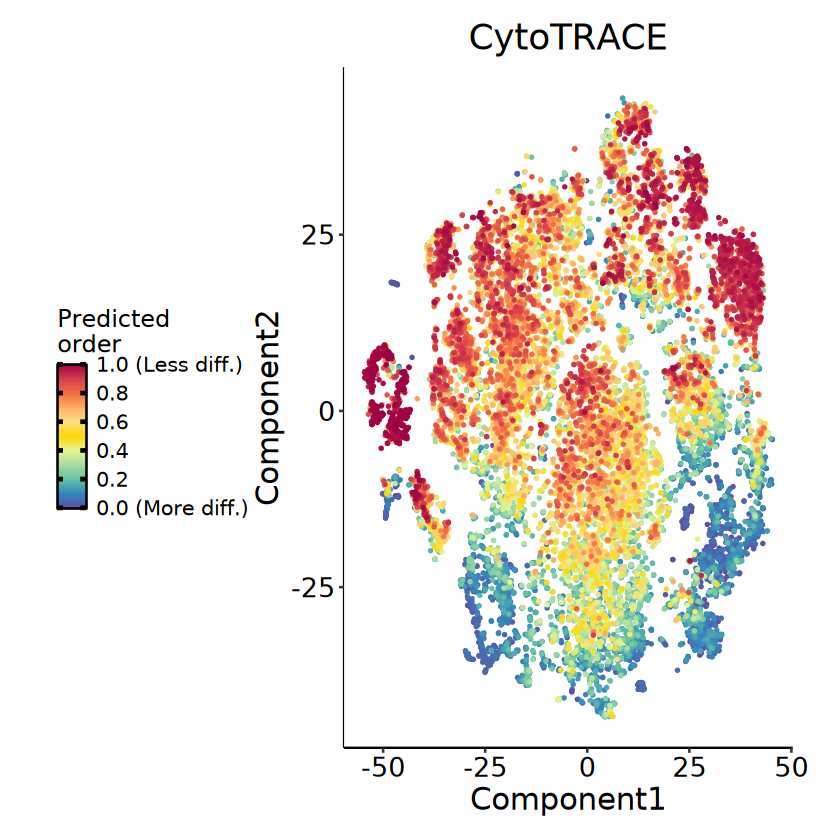

In [ ]:
plotCytoTRACE(Results_DC)
plotCytoTRACE(Results_DC2)

## Export results: 

In [ ]:
#convert the CytoTRACE results to dataframe 
df_DC <- data.frame(CytoTRACE_Predicted_order = Results_DC$CytoTRACE)
df_DC2 <- data.frame(CytoTRACE_Predicted_order = Results_DC2$CytoTRACE)

In [ ]:
head(df_DC)
head(df_DC2)

,CytoTRACE_Predicted_order
,<dbl>
GSE215120_AM1_AAATGCCCAGAGCCAA-1,0.2830568
GSE215120_AM1_ACACTGATCCACTGGG-1,0.3242836
GSE215120_AM1_ACAGCCGCAAACCTAC-1,0.5816993
GSE215120_AM1_ACCAGTAAGACTGGGT-1,0.4942182
GSE215120_AM1_ACGTCAACAAGGACTG-1,0.7556561
GSE215120_AM1_ACGTCAATCCGCATCT-1,0.7697335


,CytoTRACE_Predicted_order
,<dbl>
GSE215120_AM1_AAATGCCCAGAGCCAA-1,0.3391483
GSE215120_AM1_ACACTGATCCACTGGG-1,0.4243202
GSE215120_AM1_ACAGCCGCAAACCTAC-1,0.4366342
GSE215120_AM1_ACGTCAATCCGCATCT-1,0.4304772
GSE215120_AM1_ACTTGTTTCTGAAAGA-1,0.6870190
GSE215120_AM1_AGAGCTTGTACAGTTC-1,0.7650077


In [ ]:
write.csv(df_DC, "20260412_AllDC_CytoTRACE_Predicted_order_export.csv", row.names = TRUE)
write.csv(df_DC2, "20260412_DC2_CytoTRACE_Predicted_order_export.csv", row.names = TRUE)

# Python: transfer cytotrace predicted order back to processed object: 

In [ ]:
import scanpy as sc
import os
import pandas as pd

In [ ]:
#set current directory 
os.chdir('/scratch/user/s4436039/scdata/Myeloid_Objects')
os.getcwd()

'/scratch/user/s4436039/scdata/Myeloid_Objects'

In [ ]:
#import clean data for AllDC and DC2:
data_DC = sc.read_h5ad('20250617_AllDC_bbknn.h5ad')
data_DC2 = sc.read_h5ad('20250629_DC2_bbknn_clustered2.h5ad')

In [ ]:
data_DC2

AnnData object with n_obs × n_vars = 16643 × 2001
    obs: 'nCount_RNA', 'nFeature_RNA', 'sample_type', 'cancer_type', 'patient_id', 'sample_id', 'percent.mt', 'site', 'sample_type_major', 'cancer_subtype', 'integration_id', 'ident', 'dataset_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'S_score', 'G2M_score', 'keep_or_remove', 'leiden', 'celltype', 'leiden_DC', 'leiden_DC_v2', 'exclude_annots', 'leiden_M', 'Technology', 'NR_annotations_simple', 'sample_type_major2', 'cancer_with_H', 'cancer_broadest', 'patient_treatment', 'Guimaraes_DC2_FCER1A', 'Guimaraes_DC2_AREG', 'Guimaraes_Cheng_DC2_CD207/CD1A', 'Guimaraes_DC3_CD14', 'Guimaraes_DC4_FCGR3A', 'Guimaraes_DC_CXCL2', 'Cheng_DC2_CXCR4', 'Cheng_DC2_IL1B', 'Cheng_DC2_FCN1', 'Cheng_DC2_ISG15', 'Cheng_DC2_CXCL9', 

In [ ]:
# read in csv's
Cyto_DC = pd.read_csv('20260412_AllDC_CytoTRACE_Predicted_order_export.csv', index_col=0)
Cyto_DC2 = pd.read_csv('20260412_DC2_CytoTRACE_Predicted_order_export.csv', index_col=0)

In [ ]:
Cyto_DC.head()

,CytoTRACE_Predicted_order
GSE215120_AM1_AAATGCCCAGAGCCAA-1,0.283057
GSE215120_AM1_ACACTGATCCACTGGG-1,0.324284
GSE215120_AM1_ACAGCCGCAAACCTAC-1,0.581699
GSE215120_AM1_ACCAGTAAGACTGGGT-1,0.494218
GSE215120_AM1_ACGTCAACAAGGACTG-1,0.755656


In [ ]:
Cyto_DC2.head()

,CytoTRACE_Predicted_order
GSE215120_AM1_AAATGCCCAGAGCCAA-1,0.339148
GSE215120_AM1_ACACTGATCCACTGGG-1,0.424320
GSE215120_AM1_ACAGCCGCAAACCTAC-1,0.436634
GSE215120_AM1_ACGTCAATCCGCATCT-1,0.430477
GSE215120_AM1_ACTTGTTTCTGAAAGA-1,0.687019


In [ ]:
#check indices match
print(set(Cyto_DC.index).issubset(set(data_DC.obs.index)))
print(set(Cyto_DC2.index).issubset(set(data_DC2.obs.index)))

True
True


In [ ]:
# Add the scores to the object metadata
data_DC.obs['CytoTRACE_DC_Predicted_order_2026'] = data_DC.obs.index.map(Cyto_DC['CytoTRACE_Predicted_order'])
data_DC2.obs['CytoTRACE_DC2_Predicted_order_2026'] = data_DC2.obs.index.map(Cyto_DC2['CytoTRACE_Predicted_order'])

In [ ]:
data_DC2

AnnData object with n_obs × n_vars = 16643 × 2001
    obs: 'nCount_RNA', 'nFeature_RNA', 'sample_type', 'cancer_type', 'patient_id', 'sample_id', 'percent.mt', 'site', 'sample_type_major', 'cancer_subtype', 'integration_id', 'ident', 'dataset_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'S_score', 'G2M_score', 'keep_or_remove', 'leiden', 'celltype', 'leiden_DC', 'leiden_DC_v2', 'exclude_annots', 'leiden_M', 'Technology', 'NR_annotations_simple', 'sample_type_major2', 'cancer_with_H', 'cancer_broadest', 'patient_treatment', 'Guimaraes_DC2_FCER1A', 'Guimaraes_DC2_AREG', 'Guimaraes_Cheng_DC2_CD207/CD1A', 'Guimaraes_DC3_CD14', 'Guimaraes_DC4_FCGR3A', 'Guimaraes_DC_CXCL2', 'Cheng_DC2_CXCR4', 'Cheng_DC2_IL1B', 'Cheng_DC2_FCN1', 'Cheng_DC2_ISG15', 'Cheng_DC2_CXCL9', 

# Visualise Cytotrace (pseudotime)

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
# Set colours for NR_annotations_simple plot:
data_DC.uns["NR_annotations_simple_colors"] = ['#e377c2', '#aa40fc', '#8c564b']  

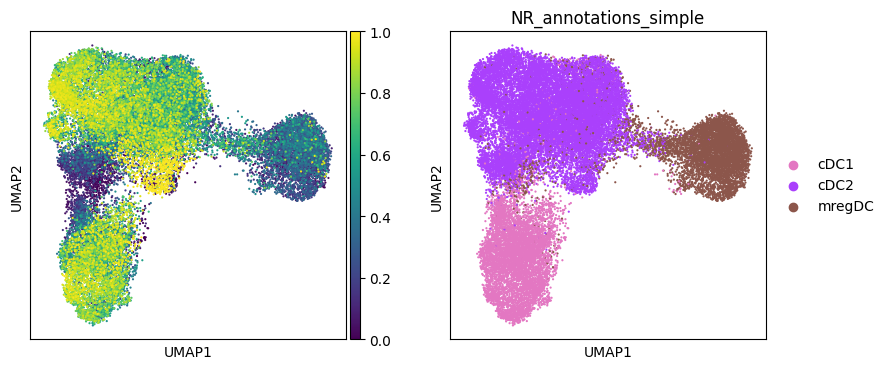

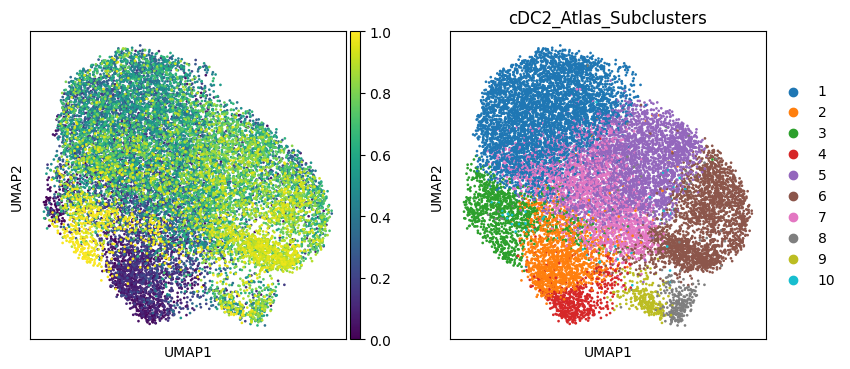

In [ ]:
#plot cytotrace predictions. 1 --> less diff., 0 --> more diff.
with plt.rc_context({"figure.figsize": (4, 4)}):
    sc.pl.umap(data_DC, color=["CytoTRACE_DC_Predicted_order_2026","NR_annotations_simple"], size=10, title="")
    sc.pl.umap(data_DC2, color=["CytoTRACE_DC2_Predicted_order_2026","cDC2_Atlas_Subclusters"], size=15, title="")

In [ ]:
# Export object with Cytotrace scores:
data_DC.write_h5ad("20260412_AllDC_Cytotrace.h5ad", compression="gzip")
data_DC2.write_h5ad("20260412_DC2_Cytotrace.h5ad", compression="gzip")

# Trajectory using Monocle3 in R

* originally tried making new env (which didn't work), somehow this broke my normal env and packages run above (eg. seurat) would now now longer load, i tried to revert to env revision 15 (Dec 2025) but still had compatability problems
* therefore decided to make two new envs and keep r and python seperate from now on (from this point forward R and python versions are as below)
* first made r env:

``` bash
    conda create -n envr26 \
        r-base=4.4 \
        r-essentials \
        r-devtools \
        r-seurat \
        r-reticulate \
        r-remotes \
        r-biocmanager \
        r-monocle3 \
        bioconductor-zellkonverter \
        -c conda-forge -c bioconda

    conda activate envr26

    R
    install.packages("devtools")
    BiocManager::install(c("SingleCellExperiment", "Biobase"))
    # download CytoTrace package: https://cytotrace.stanford.edu/
    options(repos = BiocManager::repositories())
```
``` bash
    conda install -c conda-forge libnetcdf
    R
```
``` R
    BiocManager::install(c("ncdf4", "HiClimR", "sva"))

    devtools::install_local("/scratch/user/s4436039/software/CytoTRACE/CytoTRACE_0.3.3.tar.gz")
    library(CytoTRACE)

    conda create -n envpy26 \
        python=3.11 \
        scanpy \
        anndata \
        pandas \
        scipy \
        scvelo \
        matplotlib \
        seaborn \
        tqdm \
        ipykernel \
        -c conda-forge

    conda activate envpy26


```

# Set up new env for monocle3 dependencies (make sure then switch to this env for below code)- didn't work
``` bash
conda create -n monocle3_env r-base=4.3
conda activate monocle3_env
conda install -c bioconda bioconductor-monocle3 
```

In [2]:
library(Seurat)
library(sceasy)
library(reticulate)

Loading required package: SeuratObject

Loading required package: sp




Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t




ERROR: Error: package or namespace load failed for ‘Seurat’ in loadNamespace(i, c(lib.loc, .libPaths()), versionCheck = vI[[i]]):
 there is no package called ‘shiny’


In [3]:
.libPaths()

[1] "/home/s4436039/miniforge3/envs/env/lib/R/library"

In [4]:
installed.packages()["shiny", ]

ERROR: Error in installed.packages()["shiny", ]: subscript out of bounds


In [5]:
install.packages("shiny", repos="https://cloud.r-project.org")

Warning message in install.packages("shiny", repos = "https://cloud.r-project.org"):
“installation of package ‘shiny’ had non-zero exit status”
Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done



In [6]:
library(Seurat)

ERROR: Error: package or namespace load failed for ‘Seurat’ in loadNamespace(i, c(lib.loc, .libPaths()), versionCheck = vI[[i]]):
 there is no package called ‘shiny’


In [1]:
library(BiocGenerics)
library(DelayedArray)
library(DelayedMatrixStats)
library(limma)
library(lme4)
library(S4Vectors) 
library(SingleCellExperiment)
library(SummarizedExperiment)
library(batchelor)
library(HDF5Array)
library(ggrastr)
library(devtools)
library(BPCells)


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, setdiff, sort,
    table, tapply, union, unique, unsplit, which.max, which.min


Loading required package: stats4

Loading required package: Matrix

Loading required package: MatrixGenerics

Loading required package: matrixStats


Attaching package: ‘MatrixGenerics’


The following objects are masked from ‘package:matrixStats’:

    colAlls, colAnyNAs, colAnys, colAvgsPerRowSet, colCollapse,
    colCounts, colCummaxs, colCummins, colCumprods, colCumsums,
    colDiffs, colIQRDiffs, colIQRs, colLog

ERROR: Error: package or namespace load failed for ‘devtools’ in loadNamespace(i, c(lib.loc, .libPaths()), versionCheck = vI[[i]]):
 there is no package called ‘shiny’


In [ ]:
library(BiocGenerics)
library(DelayedArray)
library(DelayedMatrixStats)
library(limma)
library(lme4)
library(S4Vectors) 
library(SingleCellExperiment)
library(SummarizedExperiment)
library(batchelor)
library(HDF5Array)
library(ggrastr)
library(devtools)
library(BPCells)

library(monocle3)
library(zellkonverter)

In [ ]:
devtools::install_github('cole-trapnell-lab/monocle3')

BPCells      (de87d4569... -> 28759cdd5...) [GitHub]
speedglm     (0.3-5        -> ca34b4e53...) [GitHub]
rlang        (1.1.4        -> 1.2.0       ) [CRAN]
lifecycle    (1.0.4        -> 1.0.5       ) [CRAN]
cli          (3.6.3        -> 3.6.6       ) [CRAN]
viridisLite  (0.4.2        -> 0.4.3       ) [CRAN]
R6           (2.5.1        -> 2.6.1       ) [CRAN]
cpp11        (0.5.1        -> 0.5.4       ) [CRAN]
vctrs        (0.6.5        -> 0.7.3       ) [CRAN]
scales       (1.3.0        -> 1.4.0       ) [CRAN]
S7           (NA           -> 0.2.1       ) [CRAN]
isoband      (0.2.7        -> 0.3.0       ) [CRAN]
utf8         (1.2.4        -> 1.2.6       ) [CRAN]
pillar       (1.10.0       -> 1.11.1      ) [CRAN]
magrittr     (2.0.3        -> 2.0.5       ) [CRAN]
tibble       (3.2.1        -> 3.3.1       ) [CRAN]
generics     (0.1.3        -> 0.1.4       ) [CRAN]
BH           (1.84.0-0     -> 1.90.0-1    ) [CRAN]
Rcpp         (1.0.13-1     -> 1.1.1       ) [CRAN]
matrixStats  (1.4.1        

Skipping 1 packages not available: grr

Skipping 29 packages ahead of CRAN: S4Arrays, IRanges, S4Vectors, MatrixGenerics, BiocGenerics, GenomeInfoDbData, zlibbioc, XVector, GenomeInfoDb, Rhdf5lib, rhdf5filters, DelayedArray, Biobase, sparseMatrixStats, beachmat, DelayedMatrixStats, SummarizedExperiment, GenomicRanges, BiocParallel, SingleCellExperiment, ScaledMatrix, rhdf5, ResidualMatrix, scuttle, BiocSingular, BiocNeighbors, limma, HDF5Array, batchelor

Installing 100 packages: rlang, lifecycle, cli, viridisLite, R6, cpp11, vctrs, scales, S7, isoband, utf8, pillar, magrittr, tibble, generics, BH, Rcpp, matrixStats, RCurl, DBI, proxy, wk, e1071, units, s2, classInt, sp, otel, later, promises, digest, base64enc, htmltools, rappdirs, fs, sass, mime, jsonlite, stringr, purrr, dplyr, warp, parallelly, listenv, globals, future, lazyeval, tinytex, bslib, xfun, highr, evaluate, yaml, rmarkdown, knitr, openssl, curl, rbibutils, Rdpack, textshaping, systemfonts, ggplot2, futile.logger, irlba, 

Warning message in i.p(...):
“installation of package ‘spdep’ had non-zero exit status”


In [ ]:
BiocManager::install("zellkonverter")

In [1]:
library(monocle3)
library(zellkonverter)

Loading required package: Biobase

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, setdiff, sort,
    table, tapply, union, unique, unsplit, which.max, which.min


Welcome to Bioconductor

    Vignettes contain introductory material; view with
    'browseVignettes()'. To cite Bioconductor, see
    'citation("Biobase")', and for packages 'citation("pkgname")'.


Loading required package: SingleCellExperiment

Loading required package: SummarizedExperiment

Loading required package: MatrixGenerics

Loading

ERROR: Error: package or namespace load failed for ‘monocle3’ in loadNamespace(j <- i[[1L]], c(lib.loc, .libPaths()), versionCheck = vI[[j]]):
 there is no package called ‘terra’


## Monocle for DC2 object

In [ ]:
#set wd
setwd('/scratch/user/s4436039/scdata/Myeloid_Objects')
getwd()

In [ ]:
# convert Anndata to Monocle cell_data_set object
cds <- readH5AD("20260412_DC2_Cytotrace.h5ad")

In [ ]:
# monocle preprocessing
cds <- preprocess_cds(cds, num_dim = 50)
cds <- reduce_dimension(cds)   # UMAP
cds <- cluster_cells(cds)

In [ ]:
# learn trajectory graph
cds <- learn_graph(cds)

## define root (least differentiated cells based on cytotrace score - high score)

In [ ]:
#check cytotrace scores are in object
summary(colData(cds)$cytotrace)

In [ ]:
#pick root cells - top 10% of cytotrace scores
ct <- colData(cds)$cytotrace

root_cells <- colnames(cds)[
  which(ct >= quantile(ct, 0.9, na.rm = TRUE))
]

In [ ]:
#order cells in pseucotime
cds <- order_cells(cds, root_cells = root_cells)

In [ ]:
# plot
plot_cells(cds, color_cells_by = "pseudotime")
plot_cells(cds, color_cells_by = "leiden")
plot_cells(cds, color_cells_by = "cytotrace")